In [89]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## Basic Data Information

##### Height_cm — Height of the individual in centimeters
##### Weight_kg — Weight of the individual in kilograms
##### Gender — Gender of the individual (Male / Female)
##### Age — Age in years
##### BMI — Body Mass Index calculated from height and weight
##### Weight_Category — BMI-based category (Underweight, Normal, Overweight, Obese)
##### Systolic_BP — Systolic blood pressure reading
##### Diastolic_BP — Diastolic blood pressure reading
##### Cholesterol_Level — Cholesterol level indicator
##### Physical_Activity_Level — Level of physical activity
##### Smoking_Status — Smoking habit indicator
##### Health_Risk_Score — Derived health risk metric
##### Activity_Index — Numeric representation of lifestyle activity

In [90]:
df = pd.read_csv(r"C:\Users\Ayobami Adeyemo\Downloads\archive (15)\weight-height.csv")
df.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker
0,161.72,53.80,Female,19,20.57,Normal,Sedentary,140,90,High,150,Normal,No
1,171.99,76.12,Male,56,25.73,Overweight,Lightly Active,122,73,Elevated,192,Normal,No
2,179.51,87.38,Male,69,27.12,Overweight,Sedentary,126,97,High,231,Borderline,No
3,179.68,74.28,Male,20,23.01,Normal,Very Active,102,71,Normal,235,Borderline,No
4,162.94,62.76,Female,54,23.64,Normal,Lightly Active,126,60,Elevated,249,High,No


## EDA

In [91]:
df.shape

(50000, 13)

In [92]:
df.describe()

,Height,Weight,Age,BMI,Systolic_BP,Diastolic_BP,Cholesterol
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,168.791384,67.349698,49.068700,23.504342,120.220500,80.11208,202.175240
std,9.886864,11.206605,18.213465,2.279060,14.726255,9.83213,36.331602
min,145.000000,45.000000,18.000000,15.830000,90.000000,60.00000,150.000000
25%,161.540000,59.080000,33.000000,21.940000,110.000000,73.00000,173.000000
50%,168.450000,66.570000,49.000000,23.440000,120.000000,80.00000,200.000000
75%,175.730000,75.020000,65.000000,25.000000,130.000000,87.00000,227.000000
max,200.000000,111.330000,80.000000,34.460000,176.000000,120.00000,300.000000


In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Height                50000 non-null  float64
 1   Weight                50000 non-null  float64
 2   Gender                50000 non-null  str    
 3   Age                   50000 non-null  int64  
 4   BMI                   50000 non-null  float64
 5   Weight_Category       50000 non-null  str    
 6   Activity_Level        50000 non-null  str    
 7   Systolic_BP           50000 non-null  int64  
 8   Diastolic_BP          50000 non-null  int64  
 9   BP_Category           50000 non-null  str    
 10  Cholesterol           50000 non-null  int64  
 11  Cholesterol_Category  50000 non-null  str    
 12  Smoker                50000 non-null  str    
dtypes: float64(3), int64(4), str(6)
memory usage: 5.0 MB


In [94]:
df.isnull().sum()

Height                  0
Weight                  0
Gender                  0
Age                     0
BMI                     0
Weight_Category         0
Activity_Level          0
Systolic_BP             0
Diastolic_BP            0
BP_Category             0
Cholesterol             0
Cholesterol_Category    0
Smoker                  0
dtype: int64

In [95]:
df[['Age', 'Height']].corr()

,Age,Height
Age,1.000000,-0.004422
Height,-0.004422,1.000000


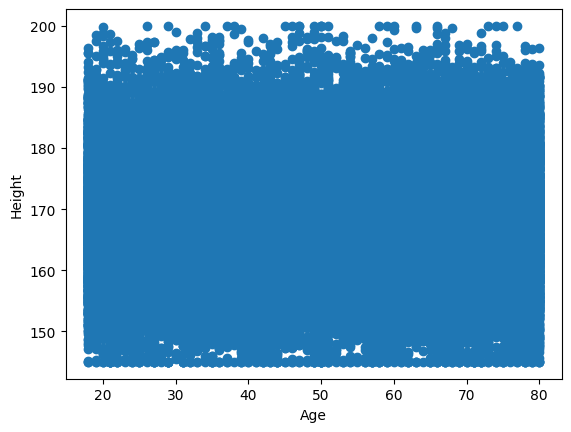

In [96]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Height'])
plt.xlabel("Age")
plt.ylabel("Height")
plt.show()

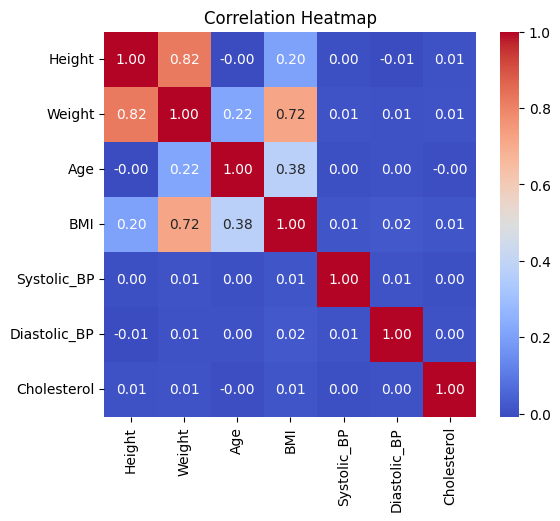

In [97]:
numeric_df = df.select_dtypes(include='number')

# Step 2: Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Visualize with a Seaborn Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

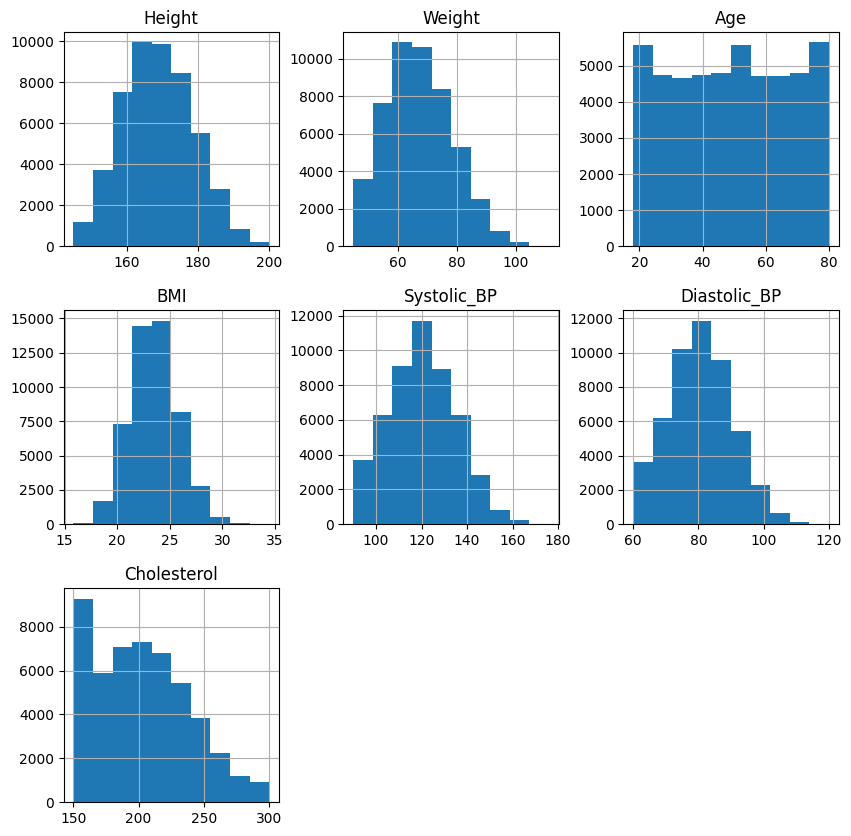

In [98]:
histplot = df.hist(column = ['Height', 'Weight', 'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol'], figsize=(10,10))



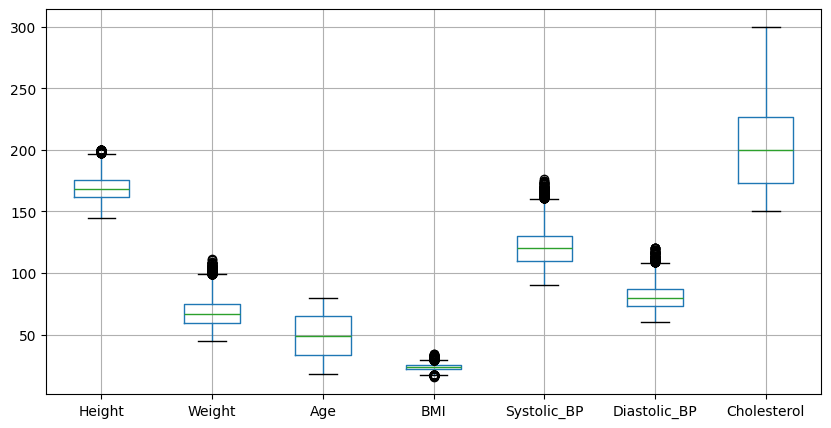

In [99]:
plt.subplots(figsize=(10,5))
boxplot = df.boxplot(column = ['Height', 'Weight', 'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol'])
plt.show(boxplot)

In [100]:
#sns.pairplot(df, hue="Height")
#plt.show()

In [101]:
df.groupby('Weight_Category')['Height'].count()

Weight_Category
Normal         36993
Obese            175
Overweight     12383
Underweight      449
Name: Height, dtype: int64

In [102]:
weight_category_map = {
    'Underweight': 0,
    'Normal': 1,
    'Overweight': 2,
    'Obese': 3
}

df['Weight_Category'] = df['Weight_Category'].map(weight_category_map)

In [103]:
df.Activity_Level.value_counts()

Activity_Level
Lightly Active       17596
Sedentary            16955
Moderately Active    11621
Very Active           3828
Name: count, dtype: int64

In [104]:
activity_level_map = {
    'Lightly Active': 0,
    'Sedentary': 1,
    'Moderately Active': 2,
    'Very Active': 3}
df['Activity_Level'] = df['Activity_Level'].map(activity_level_map)



In [105]:
df.BP_Category.value_counts()

BP_Category
Elevated    25575
High        12687
Normal      11738
Name: count, dtype: int64

In [106]:
bp_category_map = {
    'Normal': 0,
    'High': 1,
    'Elevated': 2
}

df['BP_Category'] = df['BP_Category'].map(bp_category_map)

In [107]:
df.Cholesterol_Category.value_counts()

Cholesterol_Category
Normal        24724
Borderline    17041
High           8235
Name: count, dtype: int64

In [108]:
cholesterol_map = {
    'Normal': 0,
    'Borderline': 1,
    'High': 2
}

df['Cholesterol_Category'] = df['Cholesterol_Category'].map(cholesterol_map)

In [109]:
df.Smoker.value_counts()

Smoker
No     43640
Yes     6360
Name: count, dtype: int64

In [110]:
smoker_map = {
    'Yes': 1,
    'No': 0
}
df['Smoker'] = df['Smoker'].map(smoker_map)

In [111]:
BMI_Map = [
    df['BMI'] < 18.5,
    (df['BMI'] >= 18.5) & (df['BMI'] < 25),
    (df['BMI'] >= 25) & (df['BMI'] < 30),
    df['BMI'] >= 30
]

categories = ['Underweight', 'Normal', 'Overweight', 'Obesity']

df['BMI_Category'] = np.select(
    BMI_Map,
    categories,
    default='Unknown'
)


In [112]:
df.Weight_Category.value_counts()

Weight_Category
1    36993
2    12383
0      449
3      175
Name: count, dtype: int64

In [113]:
display(df.groupby('Weight_Category')['BMI'].value_counts())

Weight_Category  BMI  
0                18.46    13
                 18.35    11
                 18.32     9
                 17.99     8
                 18.31     8
                          ..
3                31.68     1
                 30.54     1
                 30.23     1
                 32.17     1
                 32.19     1
Name: count, Length: 1416, dtype: int64

In [114]:
df['Weight_Category'].describe()

count    50000.000000
mean         1.245680
std          0.458569
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Weight_Category, dtype: float64

In [115]:
Age_Map = [
    (df['Age'] >= 18) & (df['Age'] < 30),
    (df['Age'] >= 30) & (df['Age'] < 50),
    df['Age'] >= 50
]

categories = ['Young Adult', 'Adult', 'Senior']

df['Age_Category'] = np.select(
    Age_Map,
    categories,
    default='Unknown'
)

In [116]:
df.groupby('Age_Category')['Height'].count()

Age_Category
Adult          15816
Senior         24661
Young Adult     9523
Name: Height, dtype: int64

In [117]:
df.head()

,Height,Weight,Gender,Age,BMI,Weight_Category,Activity_Level,Systolic_BP,Diastolic_BP,BP_Category,Cholesterol,Cholesterol_Category,Smoker,BMI_Category,Age_Category
0,161.72,53.80,Female,19,20.57,1,1,140,90,1,150,0,0,Normal,Young Adult
1,171.99,76.12,Male,56,25.73,2,0,122,73,2,192,0,0,Overweight,Senior
2,179.51,87.38,Male,69,27.12,2,1,126,97,1,231,1,0,Overweight,Senior
3,179.68,74.28,Male,20,23.01,1,3,102,71,0,235,1,0,Normal,Young Adult
4,162.94,62.76,Female,54,23.64,1,0,126,60,2,249,2,0,Normal,Senior


In [118]:
y = df['Height']
X = df[['Weight', 'Gender', 'Age_Category', 'Smoker']]


In [119]:
X = pd.get_dummies(
    X, columns=['Gender', 'Age_Category', 'Smoker'],
    drop_first=True
)

In [120]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(40000, 5) (10000, 5) (40000,) (10000,)


### 1. Model DecisionTreeRegressor

In [121]:
from sklearn.tree import DecisionTreeRegressor
model_dt = decision_tree_regressor = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [122]:
y_pred_dt = model_dt.predict(X_test)

In [123]:
r2_score_dt = model_dt.score(X_test, y_test)
mean_absolute_error_dt = np.mean(np.abs(y_test - y_pred_dt))
mean_squared_error_dt = np.mean((y_test - y_pred_dt) ** 2)
accuracy_dt = model_dt.score(X_test, y_test)
print(f"R2 Score: {r2_score_dt:.4f}")
print(f"Mean Absolute Error: {mean_absolute_error_dt:.4f}")
print(f"Mean Squared Error: {mean_squared_error_dt:.4f}")
print(f"Accuracy: {accuracy_dt:.4f}")

R2 Score: 0.5538
Mean Absolute Error: 5.2445
Mean Squared Error: 43.4915
Accuracy: 0.5538


### 2. Model LinearRegressor

In [124]:
from sklearn.linear_model import LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [125]:
y_pred_lr = model_lr.predict(X_test)


In [126]:
r2_score_lr = model_lr.score(X_test, y_test)
mean_absolute_error_lr = np.mean(np.abs(y_test - y_pred_lr))
mean_squared_error_lr = np.mean((y_test - y_pred_lr) ** 2)
accuracy_lr = model_lr.score(X_test, y_test)

print(f"R2 Score: {r2_score_lr:.4f}")
print(f"mean_absolute_error: {mean_absolute_error_lr:.4f}")
print(f"mean_squared_error: {mean_squared_error_lr:.4f}")
print(f"Accuracy: {accuracy_lr:.4f}")

R2 Score: 0.7273
mean_absolute_error: 4.1122
mean_squared_error: 26.5776
Accuracy: 0.7273


### 3. Model RandomForest Regressor

In [127]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [128]:
y_pred_rf = model_rf.predict(X_test)

In [129]:
r2_score_rf = model_rf.score(X_test, y_test)
mean_absolute_error_rf = np.mean(np.abs(y_test - y_pred_rf))
mean_squared_error_rf = np.mean((y_test - y_pred_rf) ** 2)
accuracy_rf = model_rf.score(X_test, y_test)

print(f"R2 Score: {r2_score_rf:.4f}")
print(f"Mean Absolute Error: {mean_absolute_error_rf:.4f}")
print(f"Mean Squared Error: {mean_squared_error_rf:.4f}")
print(f"Accuracy: {accuracy_rf:.4f}")

R2 Score: 0.6328
Mean Absolute Error: 4.7698
Mean Squared Error: 35.7848
Accuracy: 0.6328


In [130]:
Comparison_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Linear Regression', 'Random Forest'],
    'R2 Score': [r2_score_dt, r2_score_lr, r2_score_rf],
    'Mean Absolute Error': [mean_absolute_error_dt, mean_absolute_error_lr, mean_absolute_error_rf],
    'Mean Squared Error': [mean_squared_error_dt, mean_squared_error_lr, mean_squared_error_rf],
    'Accuracy': [accuracy_dt, accuracy_lr, accuracy_rf]
})
print(Comparison_table)

               Model  R2 Score  Mean Absolute Error  Mean Squared Error  \
0      Decision Tree  0.553761             5.244541           43.491466   
1  Linear Regression  0.727304             4.112236           26.577612   
2      Random Forest  0.632834             4.769823           35.784792   

   Accuracy  
0  0.553761  
1  0.727304  
2  0.632834  


In [131]:
import joblib
joblib.dump(model_lr, 'height_predictor_lr.pkl')

['height_predictor_lr.pkl']